Define Mean bias, Skill score

In [1]:
import pandas as pd
import xarray as xr
import numpy as np
import os
import glob
import re
import cftime

In [2]:
def compute_acc_msss_rmse(x: xr.DataArray, y: xr.DataArray):
    """
    ACC (Anomaly Correlation Coefficient) and MSSS (Mean Squared Skill Score)

    Parameters:
        x (xr.DataArray): model anomalies
        y (xr.DataArray): observed anomalies

    Returns:
        acc (xr.DataArray): ACC 
        msss (xr.DataArray): MSSS 
    """
    x_std = x.std(dim="time")
    y_std = y.std(dim="time")
    cov = (x * y).mean(dim="time")

    acc = cov / (x_std * y_std)
    msss = acc**2 - (acc - x_std / y_std)**2
    rmse = np.sqrt(((x - y) ** 2).mean(dim="time"))

    return acc, msss, rmse


In [3]:
output_dir = "/pscratch/sd/j/jungchoi/DCPP/_metrics"
output_grid_no = "144x72"

var_name = "tas"
eval_init_year_start = 1960
eval_init_year_end = 2016
comm_year_start = 1965
comm_year_end = 2014
"""
var_name = "pr"
eval_init_year_start = 1978
eval_init_year_end = 2016
comm_year_start = 1979
comm_year_end = 2014
"""
initialization_year_start = 1960
initialization_year_end = 2016

clim_period = "1981-2010"

print(f"%%%%%%%% start to calculate skill score for {var_name} %%%%%%%")


%%%%%%%% start to calculate skill score for tas %%%%%%%


In [4]:
# Calculate YR1, YR2, YR3, YR4 YR5 skill scores

exp_in = f"s{initialization_year_start}-s{initialization_year_end}"

# Evaluation for all available initializations
#eval_type = "init"
#exp_out = f"s{eval_init_year_start}-s{eval_init_year_end}"

# Evaluation for common period with historical experiments
eval_type = "comm"
exp_out = f"{comm_year_start}-{comm_year_end}"

#mdl_list = ['MME', 'CanESM5', 'CMCC-CM2-SR5', 'CNRM-ESM2-1', 'EC-Earth3', 'FGOALS-f3-L', 'HadGEM3-GC31-MM', 'IPSL-CM6A-LR', 'MIROC6', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'NorCPM1']
mdl_list = ['MPI-ESM1-2-HR']
#mdl_list = ['MRI-ESM2-0']

lead_year_end = 5

# Read observation climatology
obs_file = f"{output_dir}/OBS/{var_name}.{output_grid_no}.mon_clim{clim_period}.nc"    
ds = xr.open_dataset(obs_file)
obs_clim = ds.mean(dim="month")
ds.close()

# Read observation data (annual mean)
if var_name == "tas":
    obs_ann_file = f"{output_dir}/OBS/{var_name}.{output_grid_no}.1961-2021.ann.nc"
if var_name == "pr":
    obs_ann_file = f"{output_dir}/OBS/{var_name}.{output_grid_no}.1979-2021.ann.nc"

obs_ann = xr.open_dataset(obs_ann_file)
obs_ann.close()

for model in mdl_list:
    ensemble_no = 10
    if model == "FGOALS-f3-L":
        ensemble_no = 9
    if model == "MME":
        ensemble_no = 109

    xi_list = []
    x_list = []
    y_list = []

    for n, lead_year in enumerate(range(1, lead_year_end + 1)):
        
        # Read model climatology and define bias
        if model != "MME":
            mdl_file = f"{output_dir}/{model}/{var_name}.{output_grid_no}.YR{lead_year}.mon_clim{clim_period}.em.nc"    
            ds = xr.open_dataset(mdl_file)
            mdl_clim = ds.mean(dim="month")
            ds.close()
        
            bias = mdl_clim[f"{var_name}"] - obs_clim[f"{var_name}"]

            model_file = f"{output_dir}/{model}/{var_name}.{output_grid_no}.{exp_in}.YR{lead_year}.r1-{ensemble_no}.nc"    
            ds = xr.open_dataset(model_file)
            ei = ds - bias 
            em = ds.mean(dim="ensemble") - bias
            print(ds)
            ds.close()
        #print(bias)
        
        if model == "MME":
            model_file = f"{output_dir}/{model}/{var_name}_bc.{output_grid_no}.{exp_in}.YR{lead_year}.r1-{ensemble_no}.nc"    
            ds = xr.open_dataset(model_file)
            ei = ds
            em = ds.mean(dim="ensemble")
            print(ds)
            ds.close()       

        if eval_type == "init":
            target_year_start = eval_init_year_start + lead_year
            target_year_end   = eval_init_year_end + lead_year
            target_years = list(range(target_year_start, target_year_end + 1))
        if eval_type == "comm":
            target_year_start = comm_year_start 
            target_year_end   = comm_year_end 
            target_years = list(range(target_year_start, target_year_end + 1))
        #print(lead_year, target_years)
    
        # selected target years
        mei_ds = ei.sel(time=ei.time.dt.year.isin(target_years)) 
        mem_ds = em.sel(time=em.time.dt.year.isin(target_years)) 
        obs_ds = obs_ann.sel(time=obs_ann.time.dt.year.isin(target_years))
    
        print('%%% Lead year==', lead_year)
        print('%%% Model time==', mem_ds.time.dt.year)
        print('%%% OBS time==', obs_ds.time.dt.year)
    
        # Compute skill scores and std for ensemble-mean 
        x = mem_ds[f"{var_name}"] - mem_ds[f"{var_name}"].mean(dim="time")
        y = obs_ds[f"{var_name}"] - obs_ds[f"{var_name}"].mean(dim="time")
        
        acc, msss, rmse = compute_acc_msss_rmse(x,y)
        pc_obs = acc
        sig_std = x.std(dim="time")
            
        # Compute the predictable components in model
        xi_ds = []
        stdi_ds = []
        for i in range(mei_ds.sizes['ensemble']):
            xi = mei_ds[f"{var_name}"].isel(ensemble=i) - mem_ds[f"{var_name}"].mean(dim="time")
            #print('ensemble==', ens, xi)
            xi_std = xi.std(dim="time")
            stdi_ds.append(xi_std)
            xi_ds.append(xi)
            
        stdi_all = xr.concat(stdi_ds, dim="ensemble")
        xi_all = xr.concat(xi_ds, dim="ensemble")
    
        pc_mdl = sig_std / stdi_all.mean(dim="ensemble") 
        rpc = pc_obs / pc_mdl
        ##rpc = rpc.where(acc > 0)
        
        acc.name = "acc"
        msss.name = "msss"
        rmse.name = "rmse"
        rpc.name = "rpc"
        sig_std.name = "std"
        pc_mdl.name = "pcm"
    
        skill_scores0 = xr.Dataset({"acc": acc, "msss": msss, "rmse": rmse, "rpc": rpc, "std": sig_std, "pcm": pc_mdl})
     
        output_filename = f"{output_dir}/{model}/skill_scores6.{var_name}.{output_grid_no}.{exp_out}.YR{lead_year}.em.nc"
        if os.path.exists(output_filename):
            os.remove(output_filename)
        skill_scores0.to_netcdf(output_filename)
        #print('%%% leadtime, skill=', lead_year, skill_scores)
        print(f"%% Skill Scores dataset saved: {output_filename}")
       
        ###### Make YR1-YR5 averaged datasets  
        xi_all = xi_all.expand_dims(dim={"leadtime": [lead_year]})
        x = x.expand_dims(dim={"leadtime": [lead_year]})
        y = y.expand_dims(dim={"leadtime": [lead_year]})
    
        xi_list.append(xi_all)
        x_list.append(x)
        y_list.append(y)
    
    
    ### Skill scores for YR1-5 average
    xi_list = xr.concat(xi_list, dim="leadtime")
    x_list = xr.concat(x_list, dim="leadtime")
    y_list = xr.concat(y_list, dim="leadtime")
    #print('%$%%% XI_list==', xi_list)
    #print('%$%%% X_list==', x_list)
    
    # YR1-5 average
    xi_mean = xi_list.mean(dim="leadtime")
    x_mean = x_list.mean(dim="leadtime")
    y_mean = y_list.mean(dim="leadtime")
    #print(x_mean)
    
    acc, msss, rmse = compute_acc_msss_rmse(x_mean,y_mean)
    pc_obs = acc
    sig_std = x_mean.std(dim="time")
            
    # Compute the predictable components in model
    stdi_ds = []
    for i in range(xi_mean.sizes['ensemble']):
        xii = xi_mean.isel(ensemble=i)
        xi_std = xii.std(dim="time")
        stdi_ds.append(xi_std)
    stdi_all = xr.concat(stdi_ds, dim="ensemble")
    
    pc_mdl = sig_std / stdi_all.mean(dim="ensemble") 
    rpc = pc_obs / pc_mdl
    ##rpc = rpc.where(acc > 0)
    
    acc.name = "acc"
    msss.name = "msss"
    rmse.name = "rmse"
    rpc.name = "rpc"
    sig_std.name = "std"
    pc_mdl.name = "pcm"
    
    skill_scores = xr.Dataset({"acc": acc, "msss": msss, "rmse": rmse, "rpc": rpc, "std": sig_std, "pcm": pc_mdl})
    print('%%%SKill score==', skill_scores)
    
    output_filename = f"{output_dir}/{model}/skill_scores6.{var_name}.{output_grid_no}.{exp_out}.YR1-5.em.nc"
    if os.path.exists(output_filename):
        os.remove(output_filename)
    skill_scores.to_netcdf(output_filename)
    print(skill_scores)
    print(f"%% Skill Scores dataset saved: {output_filename}")  


<xarray.Dataset> Size: 26MB
Dimensions:   (ensemble: 10, time: 57, lat: 72, lon: 144, bnds: 2)
Coordinates:
  * lat       (lat) float64 576B -88.75 -86.25 -83.75 ... 83.75 86.25 88.75
  * lon       (lon) float64 1kB 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time      (time) datetime64[ns] 456B 1961-01-01 1962-01-01 ... 2017-01-01
Dimensions without coordinates: ensemble, bnds
Data variables:
    tas       (ensemble, time, lat, lon) float32 24MB 225.7 225.5 ... 259.9
    lon_bnds  (ensemble, time, lon, bnds) float64 1MB -1.25 1.25 ... 356.2 358.8
    lat_bnds  (ensemble, time, lat, bnds) float64 657kB -90.0 -87.5 ... 90.0
%%% Lead year== 1
<xarray.DataArray 'year' (time: 50)> Size: 400B
array([1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975,
       1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986,
       1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997,
       1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008,
  

<xarray.Dataset> Size: 251kB
Dimensions:  (lat: 72, lon: 144)
Coordinates:
  * lat      (lat) float64 576B -88.75 -86.25 -83.75 ... 83.75 86.25 88.75
  * lon      (lon) float64 1kB 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
    height   float64 8B 2.0
Data variables:
    acc      (lat, lon) float32 41kB 0.07821 0.07867 0.07945 ... 0.4988 0.5014
    msss     (lat, lon) float32 41kB -0.265 -0.265 -0.2647 ... 0.245 0.2472 0.25
    rmse     (lat, lon) float32 41kB 0.8441 0.8451 0.8458 ... 1.144 1.144 1.145
    rpc      (lat, lon) float32 41kB 0.1884 0.1892 0.1908 ... 0.7039 0.7082
    std      (lat, lon) float32 41kB 0.4495 0.4504 0.4513 ... 0.7113 0.7115
    pcm      (lat, lon) float32 41kB 0.4152 0.4158 0.4164 ... 0.7087 0.708


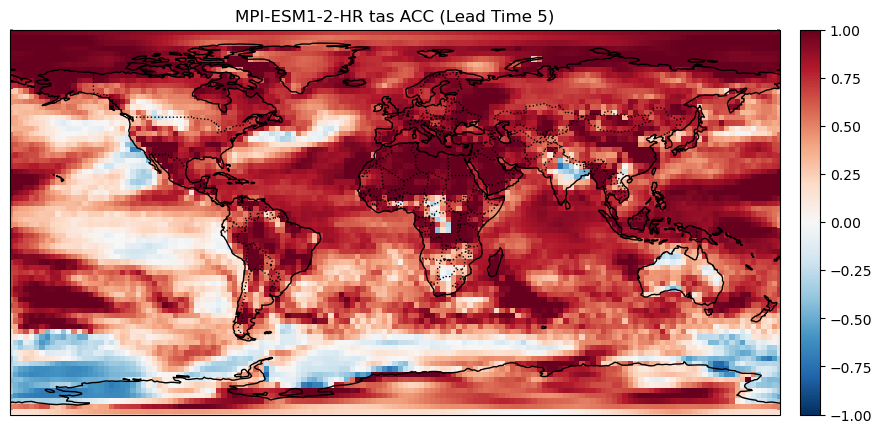

In [5]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors

#skill_scores = skill_scores.squeeze(dim="leadtime")
print(skill_scores0)
data0 = skill_scores0

data = data0["rpc"].values
lon = data0["lon"].values
lat = data0["lat"].values


# Create figure and axis with PlateCarree projection
fig, ax = plt.subplots(figsize=(10, 5), subplot_kw={'projection': ccrs.PlateCarree()})

# Add coastlines for reference
ax.add_feature(cfeature.COASTLINE, linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle=":")


# Define normalization to center at zero
#norm = mcolors.TwoSlopeNorm(vmin=data.min(), vcenter=0, vmax=data.max())
#norm = mcolors.TwoSlopeNorm(vmin=-5, vcenter=0, vmax=5)
norm = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

# Use "RdBu_r" colormap for smooth gradation from blue → white → red
mesh = ax.pcolormesh(lon, lat, data, transform=ccrs.PlateCarree(),
                      cmap="RdBu_r", norm=norm)

# Plot the climatology data
#mesh = ax.pcolormesh(lon, lat, data, transform=ccrs.PlateCarree(), cmap="coolwarm")
#contour = ax.contour(lon, lat, data, levels=np.arange(-20, 20, 1.0), 
#                     colors="black", linewidths=0.8, transform=ccrs.PlateCarree())

# Add contour labels
#ax.clabel(contour, inline=True, fontsize=8, fmt="%1.0f")

# Add colorbar
#cbar = plt.colorbar(mesh, ax=ax, orientation="vertical", pad=0.02)
#cbar.set_label("SST (°C)")

# Set title
ax.set_extent([lon.min(), lon.max(), -90, 90], crs=ccrs.PlateCarree())
ax.set_title(f"{model} {var_name} ACC (Lead Time {lead_year})")

pos = ax.get_position()  # Get axis position
cbar_ax = fig.add_axes([pos.x1 + 0.02, pos.y0, 0.02, pos.y1 - pos.y0])  # Align with figure
cbar = plt.colorbar(mesh, cax=cbar_ax)
#cbar.set_label("TAS (°C)")  # Modify label if needed

# Show plot
plt.show()
